In [1]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 77.7 MB/s eta 0:00:00


In [2]:
import pickle
from pathlib import Path

import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

2026-06-29 08:17:29.939829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782721050.111600      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782721050.161232      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782721050.551118      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782721050.551152      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782721050.551155      23 computation_placer.cc:177] computation placer alr

In [3]:
CSV_PATH = "/kaggle/input/notebooks/sumedhabhadauria/01-dataset-preparation/clean_metadata.csv"
EMBEDDINGS_PATH = "/kaggle/input/notebooks/sumedhabhadauria/03-resnet50-feature-extraction/embeddings.npy"
IMAGE_IDS_PATH = "/kaggle/input/notebooks/sumedhabhadauria/03-resnet50-feature-extraction/image_ids.pkl"
MODEL_PATH = "/kaggle/input/notebooks/sumedhabhadauria/03-resnet50-feature-extraction/feature_extractor.keras"
IMAGE_FOLDER = Path("/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images")

In [4]:
# Loading Resources

df = pd.read_csv(CSV_PATH)
embeddings = np.load(EMBEDDINGS_PATH).astype("float32")
with open(IMAGE_IDS_PATH, "rb") as f:
    image_ids = pickle.load(f)
feature_extractor = load_model(MODEL_PATH)
print("Embeddings:", embeddings.shape)
print("Image IDs :", len(image_ids))

I0000 00:00:1782721067.169545      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782721067.175436      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Embeddings: (44419, 2048)
Image IDs : 44419


In [5]:
# Building FAISS Index

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)
print("FAISS Index Created Successfully")
print("Total Indexed Images:", index.ntotal)

FAISS Index Created Successfully
Total Indexed Images: 44419


In [6]:
# Feature Extraction Function

def extract_feature(img_path):
    img = image.load_img(
        img_path,
        target_size=(224,224)
    )
    img = image.img_to_array(img)
    img = np.expand_dims(img,axis=0)
    img = preprocess_input(img)
    feature = feature_extractor.predict(
        img,
        verbose=0
    ).flatten()
    feature = feature/np.linalg.norm(feature)
    return feature.astype("float32")

In [7]:
# Similar Images Searching Function

def search_similar_images(query_image, top_k=5):
    query_feature = extract_feature(query_image)
    distances, indices = index.search(
        np.expand_dims(query_feature, axis=0),
        top_k + 1
    )
    results = []
    query_id = Path(query_image).stem

    for idx, dist in zip(indices[0], distances[0]):
        image_id = str(image_ids[idx])
        if image_id == query_id:
            continue
        results.append((image_id, dist))
        if len(results) == top_k:
            break
    return results

In [8]:
# Displaying Results

def display_results(query_image, results):
    plt.figure(figsize=(16,8))
    plt.subplot(2,3,1)
    plt.imshow(Image.open(query_image))
    plt.title("Query Image")
    plt.axis("off")

    for i,(image_id,distance) in enumerate(results):
        row = df[df["id"]==int(image_id)].iloc[0]
        img_path = IMAGE_FOLDER/f"{image_id}.jpg"
        plt.subplot(2,3,i+2)
        plt.imshow(Image.open(img_path))
        plt.title(
            f"{row['articleType']}\nDistance:{distance:.3f}",
            fontsize=10
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
query_image = IMAGE_FOLDER/"15970.jpg"
print(query_image)

/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images/15970.jpg


In [10]:
results = search_similar_images(query_image)
results

I0000 00:00:1782721073.161987      74 service.cc:152] XLA service 0x794994047cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782721073.162028      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782721073.162032      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782721073.976072      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782721076.752394      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[('15971', np.float32(0.1198957)),
 ('16408', np.float32(0.12716305)),
 ('16395', np.float32(0.13192797)),
 ('18327', np.float32(0.13414371)),
 ('13861', np.float32(0.13632786))]

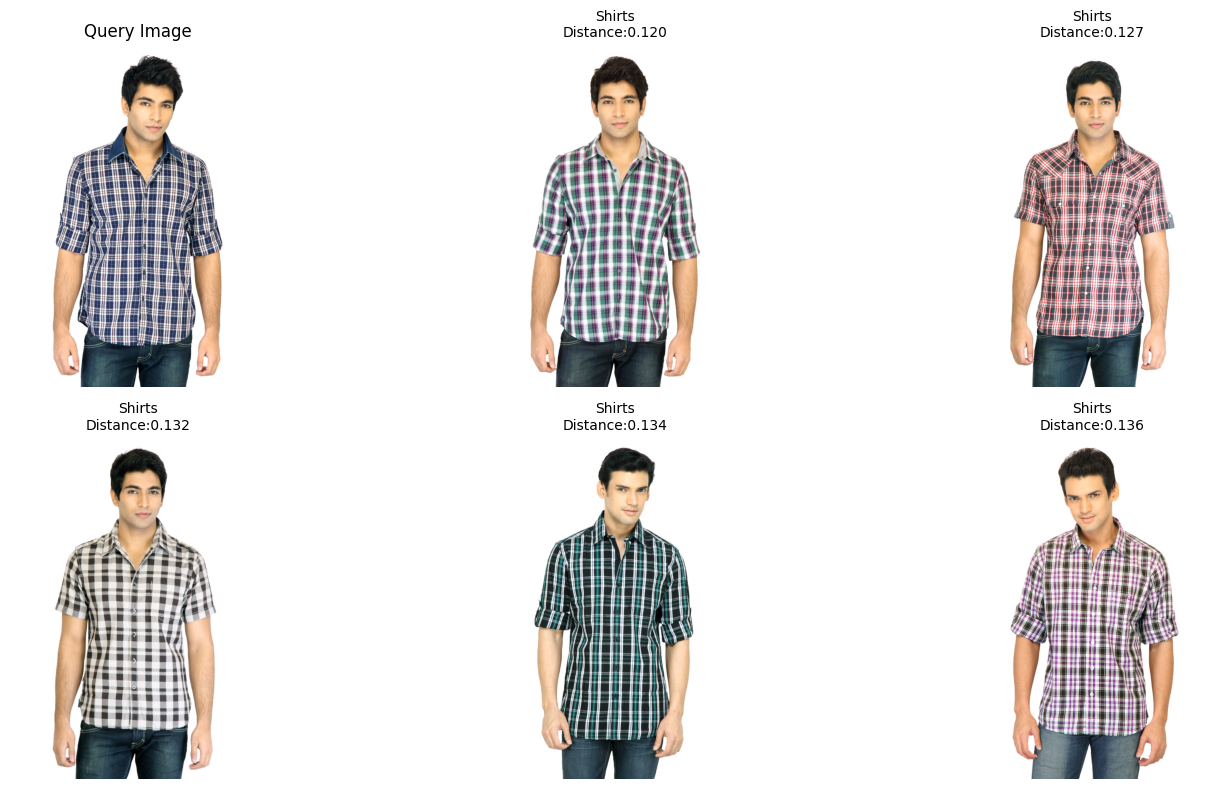

In [11]:
# Displaying Recommendations

display_results(query_image,results)

In [12]:
# Saving FAISS Index

faiss.write_index(index,"/kaggle/working/faiss_index.index")
print("FAISS Index Saved Successfully")

FAISS Index Saved Successfully


In [13]:
print("Indexed Images :", index.ntotal)
print("Embedding Dimension :", dimension)
print("Search Engine :", "FAISS IndexFlatL2")

Indexed Images : 44419
Embedding Dimension : 2048
Search Engine : FAISS IndexFlatL2
